# Data ingestion and cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from scipy import stats
import math
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold


from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

from sklearn.base import BaseEstimator, TransformerMixin

from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint, uniform
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [2]:
df = pd.read_csv("/Users/islamso/Downloads/creditcard.csv", dtype={"Class": int})
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# check the structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
# checking for duplicates

duplicates = df[df.duplicated(keep=False)]  # keep=False marks all duplicates

print("Number of exact duplicate rows:", duplicates.shape[0])
print("Preview of duplicates:")
print(duplicates.head())

Number of exact duplicate rows: 1854
Preview of duplicates:
     Time        V1        V2        V3        V4        V5        V6  \
32   26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
33   26.0 -0.529912  0.873892  1.347247  0.145457  0.414209  0.100223   
34   26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
35   26.0 -0.535388  0.865268  1.351076  0.147575  0.433680  0.086983   
112  74.0  1.038370  0.127486  0.184456  1.109950  0.441699  0.945283   

           V7        V8        V9  ...       V21       V22       V23  \
32   0.711206  0.176066 -0.286717  ...  0.046949  0.208105 -0.185548   
33   0.711206  0.176066 -0.286717  ...  0.046949  0.208105 -0.185548   
34   0.693039  0.179742 -0.285642  ...  0.049526  0.206537 -0.187108   
35   0.693039  0.179742 -0.285642  ...  0.049526  0.206537 -0.187108   
112 -0.036715  0.350995  0.118950  ...  0.102520  0.605089  0.023092   

          V24       V25       V26       V27       V28  Amount  Class

In [5]:
# Remove exact duplicates, keeping the first occurrence
df_cleaned = df.drop_duplicates(keep='first')

print("Shape before removing duplicates:", df.shape)
print("Shape after removing duplicates:", df_cleaned.shape)

Shape before removing duplicates: (284807, 31)
Shape after removing duplicates: (283726, 31)


In [6]:
# check for missing values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
# cardinality check
df.nunique()

Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663
V27       275663
V28       275663
Amount     32767
Class          2
dtype: int64

# EDA

In [9]:
desc = df.describe().T
desc["median"] = df.median(numeric_only=True)
desc["skewness"] = df.skew(numeric_only=True)
desc["variance"] = df.var(numeric_only=True)
desc

,count,mean,std,min,25%,50%,75%,max,median,skewness,variance
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000,84692.000000,-0.035568,2.255124e+09
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930,0.018109,-3.280667,3.836489e+00
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729,0.065486,-4.624866,2.726820e+00
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558,0.179846,-2.240155,2.299029e+00
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344,-0.019847,0.676292,2.004684e+00
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666,-0.054336,-2.425901,1.905081e+00
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626,-0.274187,1.826581,1.774946e+00
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494,0.040103,2.553907,1.530401e+00
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208,0.022358,-8.521944,1.426479e+00
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995,-0.051429,0.554680,1.206992e+00


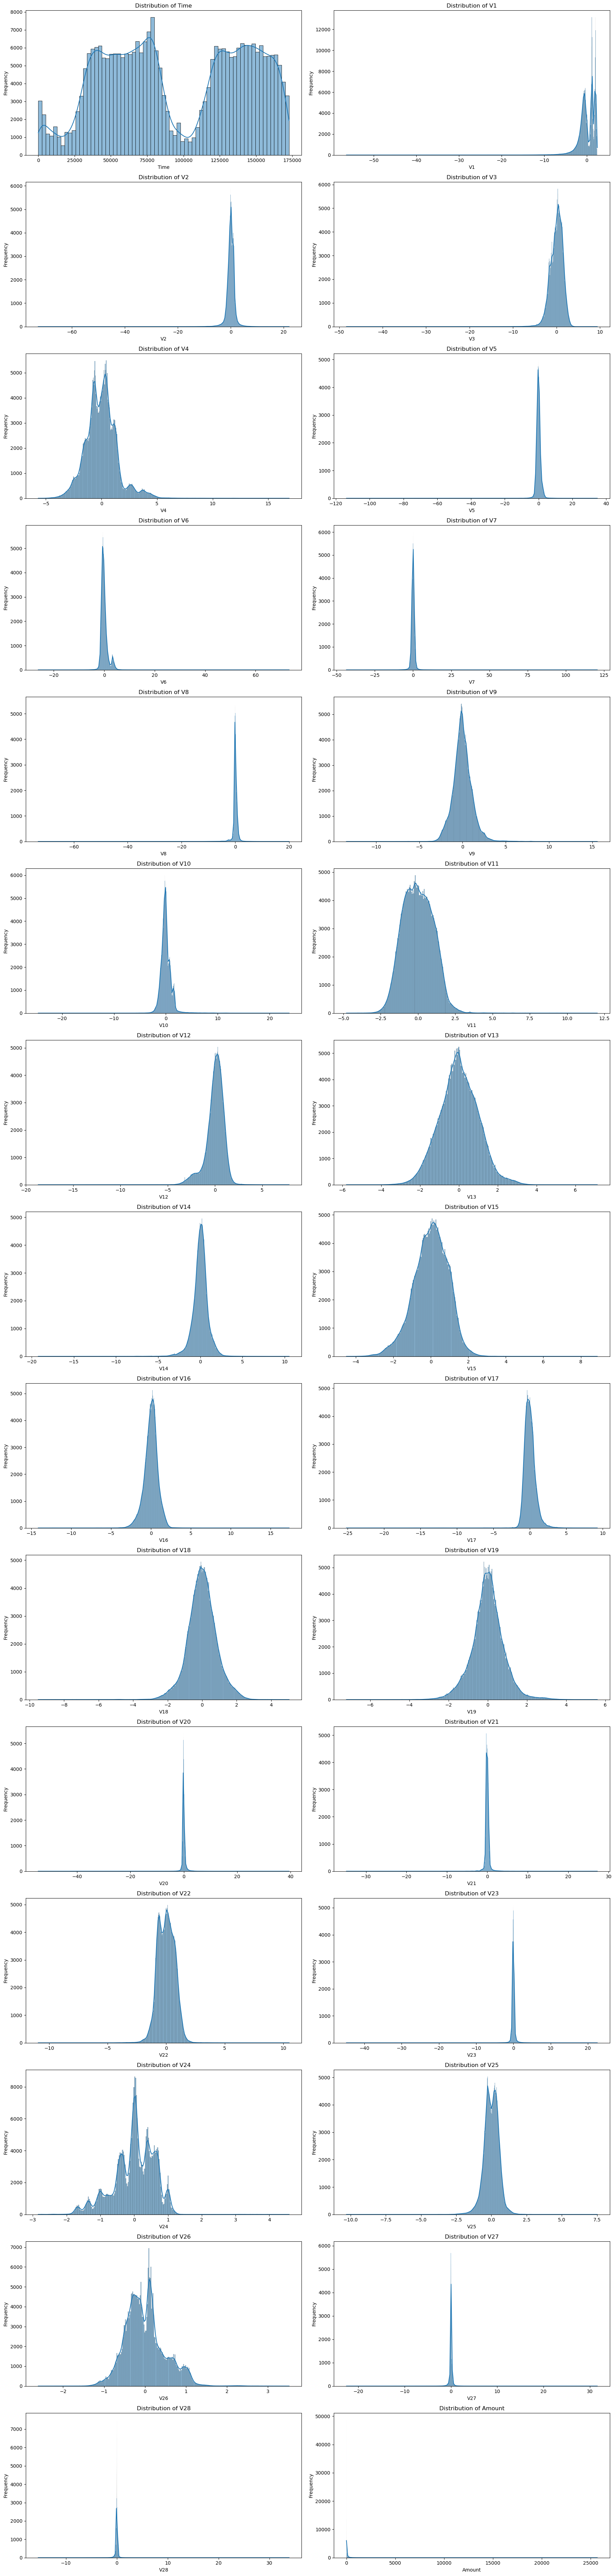

In [5]:
# Select only float columns
cols_to_plot = df.select_dtypes(include=['float']).columns

n_cols = 2
n_rows = math.ceil(len(cols_to_plot) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [6]:
# checking the target class
class_counts = df['Class'].value_counts()
print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


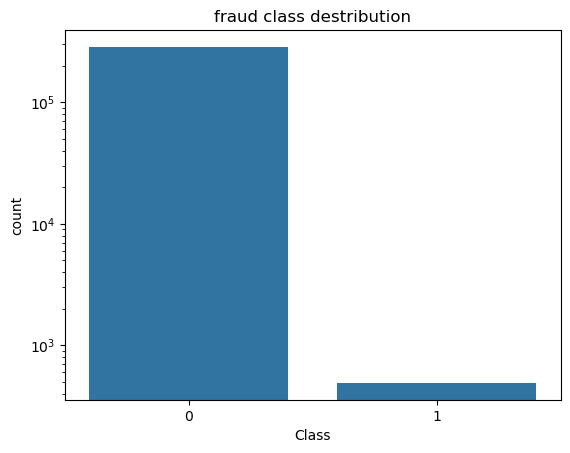

In [7]:
sns.countplot (data=df , x='Class')
plt.yscale('log')
plt.title ('fraud class destribution')
plt.show()

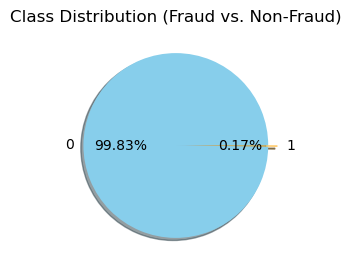

In [8]:
class_counts = df['Class'].value_counts(normalize=True) * 100
plt.figure(figsize=(3, 3))
class_counts.plot.pie(autopct='%1.2f%%', colors=['skyblue', 'orange'], explode=[0, 0.1], shadow=True)
plt.title('Class Distribution (Fraud vs. Non-Fraud)')
plt.ylabel('') # Hide the default 'Class' label on the y-axis
plt.show()

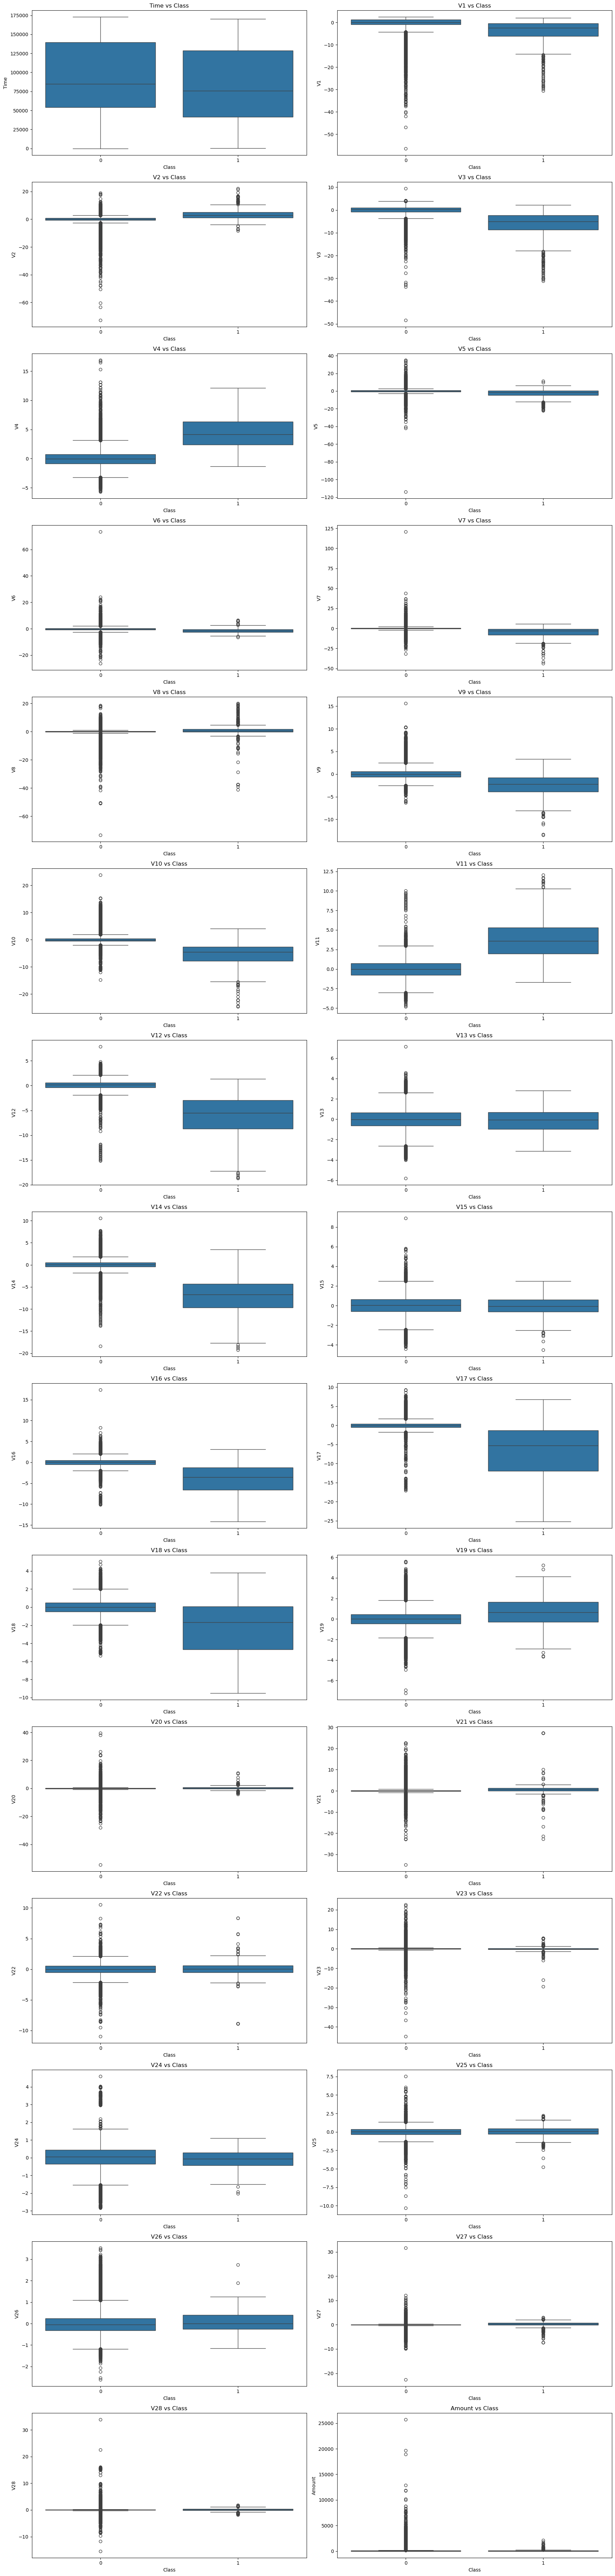

In [9]:
# Select only float columns
cols_to_plot = df.select_dtypes(include=['float']).columns

n_cols = 2
n_rows = math.ceil(len(cols_to_plot) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(n_rows, n_cols, i)
    # Seaborn boxplot with churn as x-axis
    sns.boxplot(x='Class', y=col, data=df)
    plt.title(f'{col} vs Class')
    plt.xlabel('Class')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

# Feature engineering

In [8]:
# features engineering
df["Hour"] = (df["Time"] // 3600) % 24
df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)

df["Amount_Log"] = np.log1p(df["Amount"])

df["Amount_zscore"] = (df["Amount"] - df["Amount"].mean()) / df["Amount"].std()
df["Small_Amount"] = (df["Amount"] < 10).astype(int)
df["Time_Diff"] = df["Time"].diff().fillna(0)

In [9]:
df = df.drop(["Time"], axis=1)

# Modeling

In [10]:
# split the data into train/test sets

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (227845, 36)
Test shape: (56962, 36)


In [11]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    ),



    "CatBoost": CatBoostClassifier(
        loss_function="Logloss",
        random_state=42,
        verbose=0,
        auto_class_weights="Balanced"
    )
}

In [12]:
results = []

for name, model in models.items():

    # train model
    model.fit(X_train, y_train)

    # predictions on test set
    y_pred = model.predict(X_test)

    # metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print("Confusion Matrix:")
    print(cm)

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print("\nModel Comparison:")
print(results_df)


Random Forest
Confusion Matrix:
[[56861     3]
 [   24    74]]

XGBoost
Confusion Matrix:
[[56853    11]
 [   17    81]]

CatBoost
Confusion Matrix:
[[56839    25]
 [   14    84]]

Model Comparison:
           Model  Precision    Recall  F1 Score
1        XGBoost   0.880435  0.826531  0.852632
0  Random Forest   0.961039  0.755102  0.845714
2       CatBoost   0.770642  0.857143  0.811594


In [27]:
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [200,300,400,500,700],
    "max_depth": [None,10,20,30],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": ["sqrt","log2"]
}

rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=30,
    scoring="f1",
    cv=4,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

print("RF Best F1:", rf_search.best_score_)
print("RF Best Params:", rf_search.best_params_)

Fitting 4 folds for each of 30 candidates, totalling 120 fits
RF Best F1: 0.8465835118254019
RF Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}


In [31]:
xgb = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_params = {
    "n_estimators": [200,400,600],
    "max_depth": [3,5,7],
    "learning_rate": [0.01,0.03,0.05,0.1],
    "subsample": [0.7,0.8,1],
    "colsample_bytree": [0.7,0.8,1]
}

xgb_search = RandomizedSearchCV(
    xgb,
    xgb_params,
    n_iter=25,
    scoring="f1",
    cv=4,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print("XGB Best F1:", xgb_search.best_score_)
print("XGB Best Params:", xgb_search.best_params_)

Fitting 4 folds for each of 25 candidates, totalling 100 fits
XGB Best F1: 0.8643677058391009
XGB Best Params: {'subsample': 0.8, 'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1}


In [33]:
cat = CatBoostClassifier(
    verbose=0,
    random_state=42
)

cat_params = {
    "iterations": [300,500,700],
    "depth": [4,6,8],
    "learning_rate": [0.01,0.03,0.05,0.1],
    "l2_leaf_reg": [1,3,5,7],
    "border_count": [32,64,128]
}

cat_search = RandomizedSearchCV(
    cat,
    cat_params,
    n_iter=25,
    scoring="f1",
    cv=4,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

cat_search.fit(X_train, y_train)

best_cat = cat_search.best_estimator_

print("CatBoost Best F1:", cat_search.best_score_)
print("CatBoost Best Params:", cat_search.best_params_)

Fitting 4 folds for each of 25 candidates, totalling 100 fits
CatBoost Best F1: 0.865036145208559
CatBoost Best Params: {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 700, 'depth': 8, 'border_count': 64}


In [34]:
models = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "CatBoost": best_cat
}

results = []

for name, model in models.items():

    
    y_pred = model.predict(X_test)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{name}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)

print("\nModel Comparison (Default threshold)")
print(results_df)


Random Forest
Confusion Matrix:
[[56860     4]
 [   22    76]]

XGBoost
Confusion Matrix:
[[56857     7]
 [   19    79]]

CatBoost
Confusion Matrix:
[[56860     4]
 [   20    78]]

Model Comparison (Default threshold)
           Model  Precision    Recall  F1 Score
2       CatBoost   0.951220  0.795918  0.866667
1        XGBoost   0.918605  0.806122  0.858696
0  Random Forest   0.950000  0.775510  0.853933


In [74]:
from sklearn.metrics import roc_auc_score
threshold = 0.15

models = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "CatBoost": best_cat
}

results = []

for name, model in models.items():

    # get probabilities
    probs = model.predict_proba(X_test)[:,1]

    # apply threshold
    y_pred = (probs >= threshold).astype(int)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, probs)

    print(f"\n{name}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)

print("\nModel Comparison (Threshold = 0.15)")
print(results_df)


Random Forest
Confusion Matrix:
[[56843    21]
 [   11    87]]

XGBoost
Confusion Matrix:
[[56856     8]
 [   18    80]]

CatBoost
Confusion Matrix:
[[56859     5]
 [   17    81]]

Model Comparison (Threshold = 0.15)
           Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2       CatBoost  0.999614   0.941860  0.826531  0.880435  0.979852
1        XGBoost  0.999544   0.909091  0.816327  0.860215  0.980593
0  Random Forest  0.999438   0.805556  0.887755  0.844660  0.951114
